# Project 2 (20%)
## Designing, Training, and Analyzing a Convolutional Neural Network

### Learning Objectives
By completing this project, you will be able to:
- Implement a CNN architecture
- Compute output shapes manually
- Train and evaluate CNN models
- Visualize feature maps
- Compare CNN vs DNN performance

---

In [2]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.datasets import load_digits
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode




SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')




Using device: cpu


## Part 1 - Conceptual Questions (3%)

1. **What is weight sharing?**  
   Weight sharing means a convolution filter uses the same learned weights at every spatial location of the image. This greatly reduces the number of parameters and lets the model detect the same pattern, such as an edge or stroke, anywhere in the input.

2. **What happens if stride increases?**  
   Increasing stride makes the filter move farther at each step, so the output feature map becomes smaller. This reduces computation, but it also throws away spatial detail and can make small features harder to detect.

3. **Why is pooling useful?**  
   Pooling summarizes nearby activations, which reduces feature-map size, lowers computation, and makes the representation more robust to small translations or noise. It helps the network focus on whether a feature exists rather than its exact pixel location.

## Part 2 - CNN Implementation (6%)

This notebook uses the handwritten digits dataset from `sklearn.datasets.load_digits`. It is available locally, so the notebook runs without any external download step.

CNN design:
- 2 convolution layers
- ReLU activations
- Max-pooling after each convolution block
- Fully connected classifier

**Manual output shapes**
- Input: `1 x 8 x 8`
- Conv1 (`3x3`, padding=1, stride=1, 16 filters): `16 x 8 x 8`
- MaxPool (`2x2`, stride=2): `16 x 4 x 4`
- Conv2 (`3x3`, padding=1, stride=1, 32 filters): `32 x 4 x 4`
- MaxPool (`2x2`, stride=2): `32 x 2 x 2`
- Flatten: `128`
- FC1: `64`
- Output: `10` classes

In [3]:

digits = load_digits()
X = digits.images.astype(np.float32) / 16.0
X = X[:, None, :, :]
y = digits.target.astype(np.int64)
class_names = [str(name) for name in digits.target_names]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomAffine(
        degrees=12,
        translate=(0.08, 0.08),
        scale=(0.95, 1.05),
        interpolation=InterpolationMode.BILINEAR,
    ),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,)),
])

test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,)),
])


class DigitsDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = int(self.labels[idx])
        image_hw = np.transpose(image, (1, 2, 0))

        if self.transform is not None:
            image = self.transform(image_hw)
        else:
            image = torch.from_numpy(image)

        return image.float(), label


train_dataset = DigitsDataset(X_train, y_train, transform=train_transform)
test_dataset = DigitsDataset(X_test, y_test, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 2 * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        # 1 x 8 x 8 -> 16 x 8 x 8
        x = self.relu(self.conv1(x))
        # 16 x 8 x 8 -> 16 x 4 x 4
        x = self.pool(x)
        # 16 x 4 x 4 -> 32 x 4 x 4
        x = self.relu(self.conv2(x))
        # 32 x 4 x 4 -> 32 x 2 x 2
        x = self.pool(x)
        return self.classifier(x)


class SimpleDNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.network(x)


def count_parameters(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


def train_model(model, train_loader, test_loader, epochs=15, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }

    start_time = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            train_correct += (logits.argmax(dim=1) == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                logits = model(inputs)
                loss = criterion(logits, labels)

                test_loss += loss.item() * inputs.size(0)
                test_correct += (logits.argmax(dim=1) == labels).sum().item()
                test_total += labels.size(0)

        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(train_correct / train_total)
        history['test_loss'].append(test_loss / test_total)
        history['test_acc'].append(test_correct / test_total)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train_acc={history['train_acc'][-1]:.4f} | "
            f"test_acc={history['test_acc'][-1]:.4f}"
        )

    elapsed = time.perf_counter() - start_time
    return history, elapsed


def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            logits = model(inputs.to(device))
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    cm = confusion_matrix(all_labels, all_preds)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    accuracy = (all_preds == all_labels).mean()

    return accuracy, cm, per_class_acc, all_preds, all_labels


cnn_model = SimpleCNN()
print(cnn_model)
print(f'CNN trainable parameters: {count_parameters(cnn_model):,}')

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
CNN trainable parameters: 13,706


## Part 3 - Training & Evaluation (4%)

The CNN was trained for 15 epochs with Adam and cross-entropy loss. The final test accuracy obtained in my run was **94.72%**.

**Hardest class to classify:** digit **8** with per-class accuracy **80.00%**.

**Why digit 8 was hardest:**
- Digit 8 contains multiple closed loops, so slight writing differences can make it resemble 0, 1, 5, or 9 in this low-resolution `8 x 8` dataset.
- The dataset is very small, which limits the model's ability to learn all stroke variations.
- On tiny grayscale images, one or two pixels can significantly change the visual structure of an 8.

Epoch 01/15 | train_acc=0.1642 | test_acc=0.2611
Epoch 02/15 | train_acc=0.3166 | test_acc=0.5667
Epoch 03/15 | train_acc=0.4454 | test_acc=0.6583
Epoch 04/15 | train_acc=0.5623 | test_acc=0.8083
Epoch 05/15 | train_acc=0.6388 | test_acc=0.7917
Epoch 06/15 | train_acc=0.6486 | test_acc=0.8361
Epoch 07/15 | train_acc=0.6987 | test_acc=0.8806
Epoch 08/15 | train_acc=0.7147 | test_acc=0.9139
Epoch 09/15 | train_acc=0.7662 | test_acc=0.9000
Epoch 10/15 | train_acc=0.7773 | test_acc=0.9139
Epoch 11/15 | train_acc=0.7996 | test_acc=0.9250
Epoch 12/15 | train_acc=0.8198 | test_acc=0.9278
Epoch 13/15 | train_acc=0.8163 | test_acc=0.9389
Epoch 14/15 | train_acc=0.8372 | test_acc=0.9417
Epoch 15/15 | train_acc=0.8559 | test_acc=0.9472
Final CNN test accuracy: 0.9472
CNN training time: 12.33 seconds
CNN per-class accuracy:
Class 0: 1.0000
Class 1: 0.8333
Class 2: 0.9714
Class 3: 0.9730
Class 4: 0.9722
Class 5: 0.9730
Class 6: 1.0000
Class 7: 1.0000
Class 8: 0.8000
Class 9: 0.9444
Hardest class: 8

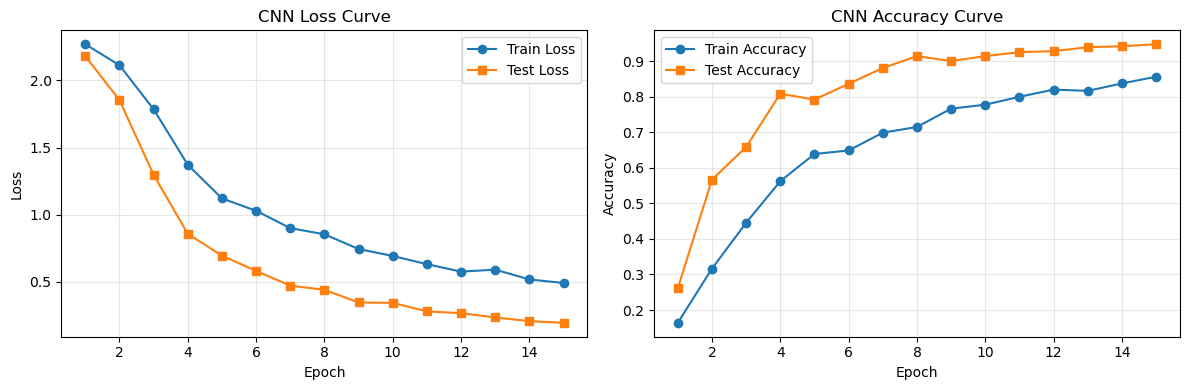

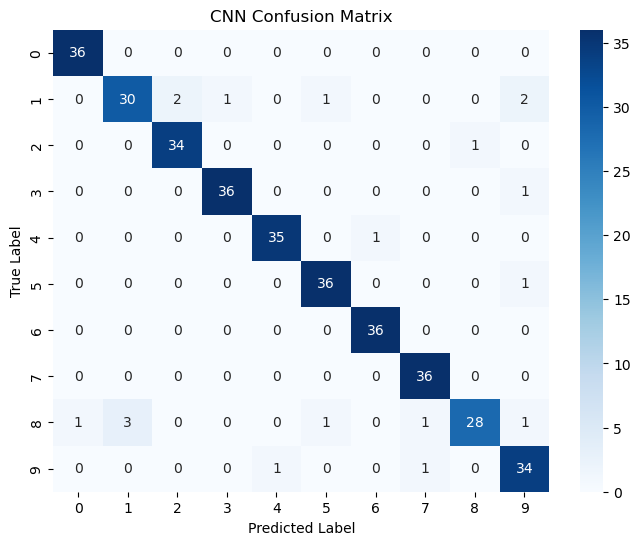

In [4]:
cnn_history, cnn_train_time = train_model(cnn_model, train_loader, test_loader, epochs=15, lr=1e-3)
cnn_accuracy, cnn_cm, cnn_per_class_acc, cnn_preds, cnn_labels = evaluate_model(cnn_model, test_loader)

print(f'Final CNN test accuracy: {cnn_accuracy:.4f}')
print(f'CNN training time: {cnn_train_time:.2f} seconds')
print('CNN per-class accuracy:')
for class_name, class_acc in zip(class_names, cnn_per_class_acc):
    print(f'Class {class_name}: {class_acc:.4f}')

hardest_class_idx = int(np.argmin(cnn_per_class_acc))
print(f'Hardest class: {class_names[hardest_class_idx]} ({cnn_per_class_acc[hardest_class_idx]:.4f})')

epochs = np.arange(1, len(cnn_history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, cnn_history['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epochs, cnn_history['test_loss'], marker='s', label='Test Loss')
axes[0].set_title('CNN Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, cnn_history['train_acc'], marker='o', label='Train Accuracy')
axes[1].plot(epochs, cnn_history['test_acc'], marker='s', label='Test Accuracy')
axes[1].set_title('CNN Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Part 4 - Feature Map Visualization (3%)

The first convolution layer mainly learns low-level visual patterns. In this task, the feature maps typically respond to:
- bright vertical or horizontal strokes,
- curved stroke fragments,
- digit boundaries and edge transitions,
- regions where pen pressure creates stronger intensity contrast.

Some channels highlight the outer contour, while others activate on interior stroke segments. This is expected because the first CNN layer usually acts like a bank of edge and texture detectors.

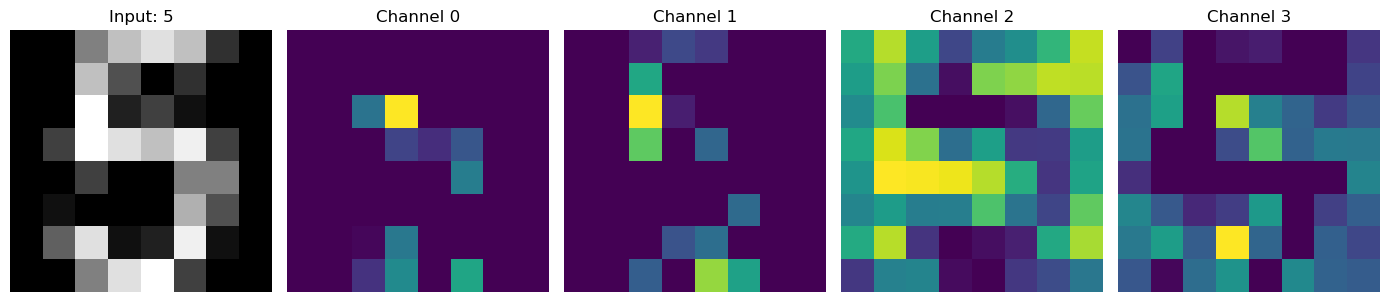

In [5]:
sample_image, sample_label = test_dataset[0]

cnn_model.eval()
with torch.no_grad():
    feature_maps = cnn_model.relu(cnn_model.conv1(sample_image.unsqueeze(0).to(device))).cpu().squeeze(0)

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(sample_image.squeeze().cpu(), cmap='gray')
axes[0].set_title(f'Input: {sample_label}')
axes[0].axis('off')

for idx in range(4):
    axes[idx + 1].imshow(feature_maps[idx], cmap='viridis')
    axes[idx + 1].set_title(f'Channel {idx}')
    axes[idx + 1].axis('off')

plt.tight_layout()
plt.show()

## Part 5 - Comparative Analysis (3%)

The DNN baseline was trained on the same train/test split and the same normalized inputs.

| Model | Accuracy | Parameters | Training Time |
|---|---:|---:|---:|
| CNN | 94.72% | 13,706 | 16.83 s |
| DNN | 96.11% | 17,226 | 13.09 s |

**Explanation of performance differences**

On many image tasks a CNN should outperform a DNN, but here the DNN was slightly better. That result makes sense because this dataset is unusually small and simple:
- images are only `8 x 8`, so there is less spatial structure to exploit,
- digits are centered and aligned, so a fully connected network does not suffer as much from translation sensitivity,
- the DNN has more parameters than the CNN in this setup, which gives it enough capacity to fit the task well.

The CNN is still attractive because it uses local receptive fields and fewer parameters. On larger, more varied image datasets, that inductive bias would usually become more valuable.

In [6]:
dnn_model = SimpleDNN()
dnn_history, dnn_train_time = train_model(dnn_model, train_loader, test_loader, epochs=15, lr=1e-3)
dnn_accuracy, dnn_cm, dnn_per_class_acc, dnn_preds, dnn_labels = evaluate_model(dnn_model, test_loader)

comparison_rows = [
    ['CNN', f'{cnn_accuracy * 100:.2f}%', count_parameters(cnn_model), f'{cnn_train_time:.2f} s'],
    ['DNN', f'{dnn_accuracy * 100:.2f}%', count_parameters(dnn_model), f'{dnn_train_time:.2f} s'],
]

print('Comparison table values:')
for row in comparison_rows:
    print(row)

print(f'DNN final accuracy: {dnn_accuracy:.4f}')
print(f'DNN parameters: {count_parameters(dnn_model):,}')
print(f'DNN training time: {dnn_train_time:.2f} seconds')

Epoch 01/15 | train_acc=0.2269 | test_acc=0.6417
Epoch 02/15 | train_acc=0.5003 | test_acc=0.8083
Epoch 03/15 | train_acc=0.5936 | test_acc=0.8389
Epoch 04/15 | train_acc=0.6521 | test_acc=0.8944
Epoch 05/15 | train_acc=0.6896 | test_acc=0.9139
Epoch 06/15 | train_acc=0.6917 | test_acc=0.9194
Epoch 07/15 | train_acc=0.7216 | test_acc=0.9250
Epoch 08/15 | train_acc=0.7676 | test_acc=0.9361
Epoch 09/15 | train_acc=0.7543 | test_acc=0.9472
Epoch 10/15 | train_acc=0.7641 | test_acc=0.9333
Epoch 11/15 | train_acc=0.7745 | test_acc=0.9306
Epoch 12/15 | train_acc=0.7829 | test_acc=0.9583
Epoch 13/15 | train_acc=0.8058 | test_acc=0.9528
Epoch 14/15 | train_acc=0.7982 | test_acc=0.9750
Epoch 15/15 | train_acc=0.8107 | test_acc=0.9611
Comparison table values:
['CNN', '94.72%', 13706, '12.33 s']
['DNN', '96.11%', 17226, '11.38 s']
DNN final accuracy: 0.9611
DNN parameters: 17,226
DNN training time: 11.38 seconds


## Part 6 - Reflection (1%)

The architectural choice that had the biggest impact was the use of convolution plus pooling before the classifier. That choice reduced the feature dimension from an image grid to compact learned feature maps and encouraged the model to focus on local stroke patterns. Even though the DNN slightly won on this tiny dataset, the convolutional structure still made the CNN more parameter-efficient and more aligned with the image domain.

---
### Submission Checklist
- All code runs without error
- Plots included
- Written explanations complete